In [1]:
import os
import shutil
import math
import random
import kagglehub

/home/utsavdas/miniconda3/envs/ml_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import time
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.utils.data.distributed import DistributedSampler
import torchvision
import torchvision.transforms as transforms
from PIL import Image
import torchvision.models as models


In [4]:
path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")
print("Path to dataset files:", path)
root = os.path.join(path, "tiny-imagenet-200")

Path to dataset files: /home/utsavdas/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1


In [ ]:
val_dir = os.path.join(root, "val")
img_dir = os.path.join(val_dir, "images")
ann = os.path.join(val_dir, "val_annotations.txt")
 
if os.path.exists(img_dir):
    with open(ann) as f:
        for line in f:
            img, cls = line.strip().split("\t")[:2]
            d = os.path.join(val_dir, cls)
            os.makedirs(d, exist_ok=True)
            src = os.path.join(img_dir, img)
            if os.path.exists(src):
                shutil.move(src, os.path.join(d, img))
    shutil.rmtree(img_dir)
 
def transform(img, train=True):
    if train:
        w, h = img.size
        if random.random() < 0.8:
            scale = random.uniform(0.2, 1.0)
            ratio = random.uniform(3./4., 4./3.)
            target_area = scale * w * h
            target_w = int(round(math.sqrt(target_area * ratio)))
            target_h = int(round(math.sqrt(target_area / ratio)))
            if target_w <= w and target_h <= h:
                i = random.randint(0, h - target_h)
                j = random.randint(0, w - target_w)
                img = img.crop((j, i, j + target_w, i + target_h))
        img = img.resize((w, h), Image.BILINEAR)
 
        if random.random() < 0.5:
            angle = random.uniform(-7, 7) 
            img = img.rotate(angle, resample=Image.BILINEAR)
 
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
 
        if random.random() < 0.8:
            from PIL import ImageEnhance
            img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))  
            img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2)) 
 
        if random.random() < 0.1: 
            from PIL import ImageFilter
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.1, 0.5))) 
 
        if random.random() < 0.1: 
            img = img.convert("L").convert("RGB")
    t = torch.from_numpy(np.array(img))
    t = t.view(64, 64, 3).permute(2,0,1).float()/255.0
    return (t - torch.tensor([0.485,0.456,0.406]).view(3,1,1)) / \
           torch.tensor([0.229,0.224,0.225]).view(3,1,1)
 
# ---- Dataset ----
class TinyImageNet(Dataset):
    def __init__(self, root, train=True):
        self.samples = []
        self.train = train
        classes = sorted([c for c in os.listdir(root) if os.path.isdir(os.path.join(root,c))])
        self.cls2idx = {c:i for i,c in enumerate(classes)}
 
        for c in classes:
            p = os.path.join(root, c)
            if not os.path.isdir(p): continue
            img_dir = os.path.join(p, "images") if os.path.isdir(os.path.join(p,"images")) else p
            for f in os.listdir(img_dir):
                if f.lower().endswith((".jpg",".jpeg",".png")):
                    self.samples.append((os.path.join(img_dir,f), self.cls2idx[c]))
    def __len__(self): return len(self.samples)
 
    def __getitem__(self, i):
        p, y = self.samples[i]
        img = Image.open(p).convert("RGB")
        return transform(img, self.train), y
 
# ---- Datasets ----
train_ds = TinyImageNet(os.path.join(root,"train"), True)
val_ds     = TinyImageNet(os.path.join(root,"val"),   False)
 

 
# ---- Loaders ----
GLOBAL_BATCH_SIZE=128
NUM_WORKERS=3
train_loader = DataLoader(
    train_ds, 
    batch_size=GLOBAL_BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    persistent_workers=True,
    drop_last = True
)
 
val_loader = DataLoader(
    val_ds, 
    batch_size=GLOBAL_BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, patch_size, stride, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.stride = stride
        self.embed_dim = embed_dim
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=stride)

    def forward(self, x):
        x = self.proj(x) 
        x = x.flatten(2)
        x = x.transpose(1, 2)

        return x
        

class PositionalEmbedding(nn.Module):
    def __init__(self, embed_dim, max_len=1000, pos_embed_type='learn'):
        super().__init__()
        self.pos_embed_type = pos_embed_type
        self.embed_dim = embed_dim
        
        if self.pos_embed_type == 'learn':
            self.pos_embedding = nn.Parameter(torch.randn(1, max_len, embed_dim) * 0.02)
            
        elif self.pos_embed_type == 'sin':
            # precompute the sinusoidal positional embeddings
            pe = torch.zeros(1, max_len, embed_dim)
            position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
            
            div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-np.log(10000.0) / embed_dim))
            
            # apply sine to even indices, cosine to odd indices
            pe[0, :, 0::2] = torch.sin(position * div_term)
            pe[0, :, 1::2] = torch.cos(position * div_term)
            
            # register as a buffer: it moves to the GPU automatically, but doesn't require gradients
            self.register_buffer('pos_embedding', pe)
    
    def forward(self, x):
        # x.shape (B, N, embed_dim)
        N = x.size(1)
        
        if self.pos_embed_type is None:
            return x
            
        elif self.pos_embed_type == 'learn':
            # slice the embedding to exactly match N, then add
            x = x + self.pos_embedding[:, :N, :]
            
        elif self.pos_embed_type == 'sin':
            # slice the precomputed buffer to exactly match N, then add
            x = x + self.pos_embedding[:, :N, :]
            
        return x
    

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.heads = heads
        self.head_dim = embed_dim // heads
        self.W_qkv = nn.Linear(embed_dim, 3*embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.linear1 = nn.Linear(embed_dim, 4*embed_dim)
        self.linear2 = nn.Linear(4*embed_dim, embed_dim)
        self.gelu = nn.GELU()

    def mhsa(self, x, return_entropy=False):
        B = x.shape[0]
        N = x.shape[1]
        qkv = self.W_qkv(x)
        q = qkv[:,:,:self.embed_dim].reshape(B,N,self.heads,self.head_dim).transpose(1,2)
        k = qkv[:,:,self.embed_dim:2*self.embed_dim].reshape(B,N,self.heads,self.head_dim).transpose(1,2)
        v = qkv[:,:,2*self.embed_dim:].reshape(B,N,self.heads,self.head_dim).transpose(1,2)
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn.softmax(dim=-1)

        head_entropies = None
        if return_entropy:
            eps = 1e-9
            entropy = -torch.sum(attn * torch.log2(attn + eps), dim=-1)
            head_entropies = entropy.mean(dim=(0, 2))                       # shape: (heads,)

        x = attn @ v
        x = x.transpose(1, 2).contiguous()
        x = x.reshape(B, N, self.embed_dim)
        x = self.proj(x)
        
        if return_entropy:
            return x, attn, head_entropies
        return x

    def mlp(self, x):
        x = self.gelu(self.linear1(x))
        x = self.linear2(x)
        return x
        

    def forward(self, x, return_entropy=False):

        if return_entropy:
            mhsa_out, attn_weights, head_entropies = self.mhsa(self.norm1(x), return_entropy=True)
            x = x + mhsa_out
            x = x + self.mlp(self.norm2(x))
            return x, attn_weights, head_entropies
        else:
            x = x + self.mhsa(self.norm1(x))
            x = x + self.mlp(self.norm2(x))
            return x
        

class VisionTransformer(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, patch_size=16, embed_dim=384, tf_blocks=12, heads=6, pos_embed='learn', stride=None, cls_token=True):
        super().__init__()
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.tf_blocks = tf_blocks
        self.pos_embed_type = pos_embed
        self.heads = heads
        if stride is None:
            self.stride = patch_size
        else:
            self.stride = stride
        self.has_cls_token = cls_token
        if self.has_cls_token:
            self.cls_token = nn.Parameter(torch.randn(1, 1, self.embed_dim) * 0.02)


        self.patch_embed = PatchEmbedding(in_channels=self.in_channels, patch_size=self.patch_size, stride=self.stride, embed_dim=self.embed_dim)
        self.pos_embedding = PositionalEmbedding(embed_dim=self.embed_dim, pos_embed_type=self.pos_embed_type)
        self.blocks = nn.ModuleList([EncoderBlock(embed_dim=self.embed_dim, heads=self.heads) for _ in range(self.tf_blocks)])

        self.norm = nn.LayerNorm(self.embed_dim)
        self.classification_head = nn.Linear(self.embed_dim, num_classes)
        
    def forward(self, x, return_entropy=False, extract_features=False):
        all_entropies = []
        attn_weights = []
        layer_features = []
        options = {}

        B = x.shape[0]
        x = self.patch_embed(x)

        # add CLS
        if self.has_cls_token:
            cls_tokens = self.cls_token.expand(B, -1, -1)
            x = torch.cat((cls_tokens, x), dim=1)
        
        x = self.pos_embedding(x)

        for encoder_block in self.blocks:
            if return_entropy:
                x, attn, layer_entropies = encoder_block(x, return_entropy=True)
                all_entropies.append(layer_entropies)
                attn_weights.append(attn)
            else:
                x = encoder_block(x)

            if extract_features:
                # get the representation immediately after the block
                if self.has_cls_token:
                    layer_features.append(x[:, 0, :]) # CLS token
                else:
                    layer_features.append(torch.mean(x, dim=1)) # Mean pooling

        if self.has_cls_token:
            x = x[:,0,:]
        else:
            x = torch.mean(x, dim=1)

        x = self.norm(x)
        x = self.classification_head(x)

        
        if return_entropy:
            options['entropies'] = torch.stack(all_entropies)
            options['attn_weights'] = torch.stack(attn_weights)
    
        if extract_features:
            options['layer_features'] = torch.stack(layer_features)
            
        if return_entropy or extract_features:
            return x, options
        
        return x



In [7]:
def train_model(model, train_loader, val_loader, checkpoint_path, epochs=20, lr=1e-3, device='cuda', criterion=None, optimizer=None, scheduler=None):
    model = model.to(device)
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
    if scheduler is None:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        
        scheduler.step(epoch_val_loss)

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc:.4f}", end="")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            if checkpoint_path is not None:
                torch.save(model.state_dict(), checkpoint_path)
                print("  -> Model Saved.")
            else:
                print()
        else:
            print()
    
              
    return history, best_val_acc

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vit_tiny1 = VisionTransformer(patch_size=4, embed_dim=192, heads=3, tf_blocks=9, num_classes=200)


In [14]:
vit_tiny_hist1, vit_tiny_best_acc1 = train_model(
    model=vit_tiny1, 
    checkpoint_path = f"best_vit_tiny1.pth",
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=100, 
    device=device
)

Epoch [1/100] | LR: 0.001000 | Train Loss: 4.9000  Acc: 0.0378 | Val Loss: 4.5551  Acc: 0.0718  -> Model Saved.
Epoch [2/100] | LR: 0.001000 | Train Loss: 4.4608  Acc: 0.0835 | Val Loss: 4.1525  Acc: 0.1140  -> Model Saved.
Epoch [3/100] | LR: 0.001000 | Train Loss: 4.1764  Acc: 0.1196 | Val Loss: 3.9372  Acc: 0.1509  -> Model Saved.
Epoch [4/100] | LR: 0.001000 | Train Loss: 4.0075  Acc: 0.1430 | Val Loss: 3.7271  Acc: 0.1816  -> Model Saved.
Epoch [5/100] | LR: 0.001000 | Train Loss: 3.8692  Acc: 0.1663 | Val Loss: 3.6547  Acc: 0.1978  -> Model Saved.
Epoch [6/100] | LR: 0.001000 | Train Loss: 3.7622  Acc: 0.1807 | Val Loss: 3.5157  Acc: 0.2154  -> Model Saved.
Epoch [7/100] | LR: 0.001000 | Train Loss: 3.6679  Acc: 0.1954 | Val Loss: 3.4341  Acc: 0.2270  -> Model Saved.
Epoch [8/100] | LR: 0.001000 | Train Loss: 3.5863  Acc: 0.2087 | Val Loss: 3.3473  Acc: 0.2446  -> Model Saved.
Epoch [9/100] | LR: 0.001000 | Train Loss: 3.5081  Acc: 0.2214 | Val Loss: 3.2864  Acc: 0.2539  -> Model

In [ ]:
vit_tiny_results1 = {}

vit_tiny_results1['hist'] = vit_tiny_hist1
vit_tiny_results1['best_val_acc'] = vit_tiny_best_acc1

In [16]:
torch.save(vit_tiny_results1, 'vit_tiny_results1.pt')

In [23]:
def plot_curves(hist, title=None):
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    if title is not None:
        fig.suptitle(title)
    l = len(hist['train_loss'])
    axes[0].plot(range(l), vit_tiny_hist1['train_loss'], label='Train Loss')
    axes[0].plot(range(l), vit_tiny_hist1['val_loss'], label='Val Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[1].plot(range(l), vit_tiny_hist1['train_acc'], label='Train Acc')
    axes[1].plot(range(l), vit_tiny_hist1['val_acc'], label='Val Acc')
    axes[1].set_title('Accuracy')
    axes[1].legend()

/tmp/ipykernel_191074/1050879756.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vit_tiny_hist1 = torch.load('vit_tiny_results1.pt')['hist']


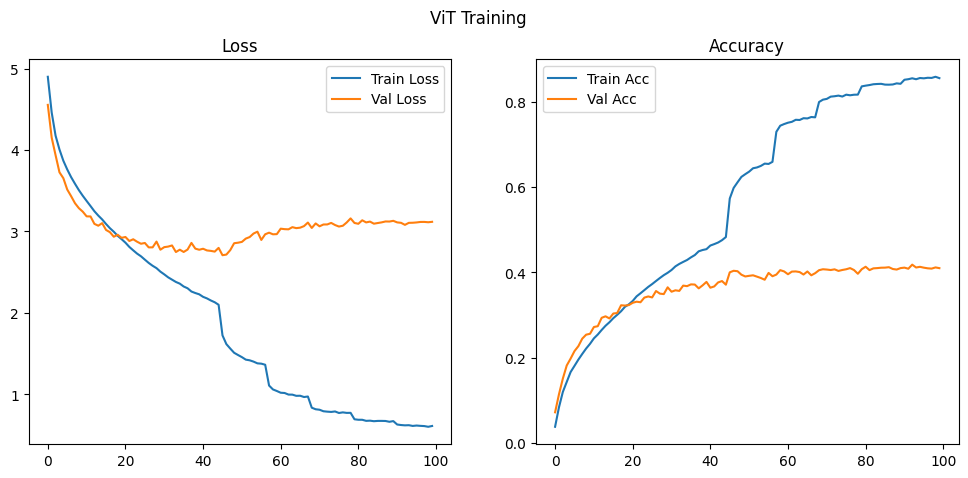

In [25]:
vit_tiny_hist1 = torch.load('vit_tiny_results1.pt')['hist']
plot_curves(vit_tiny_hist1, title='ViT Training')

In [ ]:
import torch

def calculate_topk_accuracy(outputs, labels, topk=(1, 5)):
    with torch.no_grad():
        maxk = max(topk)
        batch_size = labels.size(0)

        _, pred = outputs.topk(maxk, dim=1, largest=True, sorted=True)
        
        pred = pred.t()
        
        correct = pred.eq(labels.view(1, -1).expand_as(pred))

        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            
            res.append(correct_k.mul_(100.0 / batch_size).item())
            
        return res

In [ ]:
import torch

loaded_model = VisionTransformer(
    patch_size=4, 
    embed_dim=192, 
    heads=3, 
    tf_blocks=9, 
    num_classes=200
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model = loaded_model.to(device)

checkpoint_path = "best_vit_tiny1.pth"
loaded_model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))

loaded_model.eval()

top1_correct = 0.0
top5_correct = 0.0
total_samples = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = loaded_model(inputs)
        top1_acc, top5_acc = calculate_topk_accuracy(outputs, labels, topk=(1, 5))
        
        batch_size = labels.size(0)
        top1_correct += (top1_acc / 100.0) * batch_size
        top5_correct += (top5_acc / 100.0) * batch_size
        total_samples += batch_size

final_top1_acc = (top1_correct / total_samples) * 100.0
final_top5_acc = (top5_correct / total_samples) * 100.0

print(f"Loaded Model Top-1 Accuracy: {final_top1_acc:.2f}%")
print(f"Loaded Model Top-5 Accuracy: {final_top5_acc:.2f}%")

Loaded Model Top-1 Accuracy: 41.82%
Loaded Model Top-5 Accuracy: 64.87%


### Resnet18

In [ ]:
resnet_model = models.resnet18(weights=None)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
resnet_hist1, resnet_best_acc1 = train_model(
    model=resnet_model, 
    checkpoint_path = f"best_resnet1.pth",
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=100, 
    device=device
)


Epoch [1/100] | LR: 0.001000 | Train Loss: 4.6861  Acc: 0.0606 | Val Loss: 4.0703  Acc: 0.1175  -> Model Saved.
Epoch [2/100] | LR: 0.001000 | Train Loss: 4.0586  Acc: 0.1311 | Val Loss: 3.6303  Acc: 0.1836  -> Model Saved.
Epoch [3/100] | LR: 0.001000 | Train Loss: 3.7501  Acc: 0.1767 | Val Loss: 3.4187  Acc: 0.2246  -> Model Saved.
Epoch [4/100] | LR: 0.001000 | Train Loss: 3.5416  Acc: 0.2135 | Val Loss: 3.2311  Acc: 0.2636  -> Model Saved.
Epoch [5/100] | LR: 0.001000 | Train Loss: 3.3601  Acc: 0.2437 | Val Loss: 3.0808  Acc: 0.2869  -> Model Saved.
Epoch [6/100] | LR: 0.001000 | Train Loss: 3.2100  Acc: 0.2691 | Val Loss: 2.9479  Acc: 0.3109  -> Model Saved.
Epoch [7/100] | LR: 0.001000 | Train Loss: 3.0908  Acc: 0.2917 | Val Loss: 2.9258  Acc: 0.3148  -> Model Saved.
Epoch [8/100] | LR: 0.001000 | Train Loss: 2.9784  Acc: 0.3112 | Val Loss: 2.7368  Acc: 0.3507  -> Model Saved.
Epoch [9/100] | LR: 0.001000 | Train Loss: 2.8824  Acc: 0.3291 | Val Loss: 2.7984  Acc: 0.3430
Epoch [10

In [11]:
resnet_results1 = {}

resnet_results1['hist'] = resnet_hist1
resnet_results1['best_val_acc'] = resnet_best_acc1


In [ ]:
torch.save(resnet_results1, 'resnet_results1.pt')

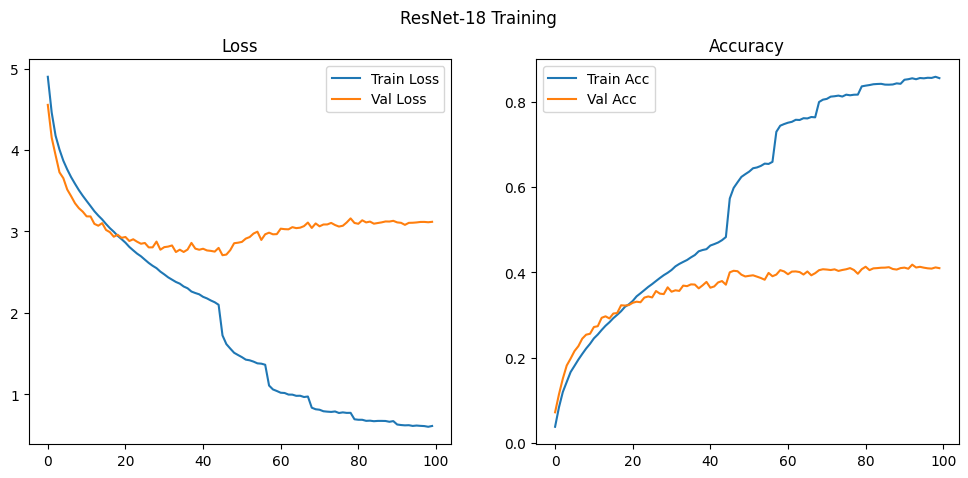

In [27]:
plot_curves(resnet_hist1, title='ResNet-18 Training')

In [ ]:
import torch
import torchvision.models as models

loaded_resnet = models.resnet18(weights=None)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_resnet = loaded_resnet.to(device)

checkpoint_path = "best_resnet1.pth"
loaded_resnet.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))

loaded_resnet.eval()

top1_correct = 0.0
top5_correct = 0.0
total_samples = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = loaded_resnet(inputs)
        
        top1_acc, top5_acc = calculate_topk_accuracy(outputs, labels, topk=(1, 5))
        
        batch_size = labels.size(0)
        top1_correct += (top1_acc / 100.0) * batch_size
        top5_correct += (top5_acc / 100.0) * batch_size
        total_samples += batch_size

final_top1_acc = (top1_correct / total_samples) * 100.0
final_top5_acc = (top5_correct / total_samples) * 100.0

print(f"Loaded ResNet-18 Top-1 Accuracy: {final_top1_acc:.2f}%")
print(f"Loaded ResNet-18 Top-5 Accuracy: {final_top5_acc:.2f}%")

Loaded ResNet-18 Top-1 Accuracy: 52.40%
Loaded ResNet-18 Top-5 Accuracy: 75.61%
